## 1. Cài Đặt & Import Thư Viện

In [ ]:
!pip install -q underthesea emoji transformers torch scikit-learn imbalanced-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.8 MB/s eta 0:00:00


In [ ]:
# Thư viện chuẩn
import os, re, time, unicodedata

# Xử lý dữ liệu
import numpy as np
import pandas as pd
from tqdm import tqdm

# Trực quan hóa
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# NLP / Tiếng Việt
import emoji
from underthesea import word_tokenize

# Deep Learning
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW

# Cài đặt hiển thị
plt.rcParams["font.family"] = "DejaVu Sans"
tqdm.pandas()

print("Import thư viện thành công!")

Import thư viện thành công!


In [ ]:
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

## 2. Đọc và Tiền xử lý dữ liệu

In [ ]:
df = pd.read_excel("/content/data_prepared.xlsx")

LABEL_NAMES = {
    0: "Bình thường",
    1: "Ít nghiêm trọng",
    2: "Nghiêm trọng",
    3: "Rất nghiêm trọng",
}

print(f"Dữ liệu: {len(df):,} rows")
print("\nPhân phối nhãn:")
print(df["label"].value_counts().sort_index())
df.head()

Dữ liệu: 74,636 rows

Phân phối nhãn:
label
0    70256
1      342
2      288
3     3750
Name: count, dtype: int64


,User,Rating,Review,Date,Thumbs_Up,Reply_Count,App_Version,Review_Id,Date_Only,Hour,Day_Name,Review_Length,label,text_clean,text_for_phobert
0,Ngọc Trần,5,oke,2026-06-01 12:49:02,0,0,11.6.1,a2879d0c-8a94-4831-a2ce-f32aec773801,2026-06-01,12,Monday,3,0,ổn,ổn
1,Mê game Wuang,5,Tuy là hơi lằng nhằng mà lúc sau thì ngon,2026-06-01 12:19:12,0,0,11.6.1,c56a91ff-a83d-40c0-a635-d1a1bcd563aa,2026-06-01,12,Monday,41,0,Tuy là hơi lằng nhằng mà lúc sau thì ngon,Tuy là hơi lằng_nhằng mà lúc sau thì ngon
2,Tổng tài Lạnh lùng,1,"thủ tục lằng nhằng, có cái đổi sdt xét 2 ngày ...",2026-06-01 12:15:02,0,0,11.6.1,bd0da53c-433a-4858-a24a-8548eab5b651,2026-06-01,12,Monday,58,3,"thủ tục lằng nhằng, có cái đổi số điện thoại x...","thủ_tục lằng_nhằng , có cái đổi số điện_thoại ..."
3,Nhung Hồng,1,như Iồn,2026-06-01 12:09:40,0,0,11.6.1,4f99139d-fa67-495f-b91f-95cf68b3edc2,2026-06-01,12,Monday,7,3,như Iồn,như Iồn
4,Uhg Yhjjjf,4,đm giờ bắt liên kết ngân hàng,2026-06-01 12:01:39,0,0,NaN,17d5ce03-9806-4d5a-a1a7-68c065ce0e3c,2026-06-01,12,Monday,29,0,đm giờ bắt liên kết ngân hàng,đm giờ bắt liên_kết ngân_hàng


## 3. Xử Lý Mất Cân Bằng Nhãn (Imbalanced)

In [ ]:
# Thống kê nhãn
df_by_label = {lbl: df[df["label"] == lbl] for lbl in range(4)}
counts      = {lbl: len(sub) for lbl, sub in df_by_label.items()}

print("Phân phối nhãn TRƯỚC khi lấy mẫu:")
print(df["label"].value_counts().sort_index().to_string())
print(f"\nSố mẫu gốc: {counts}")

# Tính target samples
MAX_OVERSAMPLE_RATIO = 5
min_count      = min(counts[1], counts[2])
TARGET_SAMPLES = min(1500, min_count * MAX_OVERSAMPLE_RATIO)
print(f"\n Target samples mỗi nhãn: {TARGET_SAMPLES}")


def safe_oversample(df_sub: pd.DataFrame, target: int, ratio_limit: int = 5) -> pd.DataFrame:
    """Oversample có giới hạn tỉ lệ để tránh overfitting."""
    n       = min(target, len(df_sub) * ratio_limit)
    replace = n > len(df_sub)
    return resample(df_sub, n_samples=n, replace=replace, random_state=42)


# Sampling
df0 = resample(df_by_label[0], n_samples=min(TARGET_SAMPLES, counts[0]), random_state=42)
df1 = safe_oversample(df_by_label[1], TARGET_SAMPLES)
df2 = safe_oversample(df_by_label[2], TARGET_SAMPLES)
df3 = safe_oversample(df_by_label[3], TARGET_SAMPLES)

df_balanced = (
    pd.concat([df0, df1, df2, df3])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("\n Phân phối nhãn SAU khi lấy mẫu:")
print(df_balanced["label"].value_counts().sort_index().to_string())

# Class weights (dùng trong loss function)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2, 3]),
    y=df_balanced["label"].tolist(),
)
print(f"\n Class weights: {class_weights}")

Phân phối nhãn TRƯỚC khi lấy mẫu:
label
0    70256
1      342
2      288
3     3750

Số mẫu gốc: {0: 70256, 1: 342, 2: 288, 3: 3750}

 Target samples mỗi nhãn: 1440

 Phân phối nhãn SAU khi lấy mẫu:
label
0    1440
1    1440
2    1440
3    1440

 Class weights: [1. 1. 1. 1.]


In [ ]:
# 1. Bỏ hàng có text_clean = NaN
df_balanced = df_balanced.dropna(subset=["text_clean"]).reset_index(drop=True)

# 2. Ép về string và strip khoảng trắng
df_balanced["text_clean"] = df_balanced["text_clean"].astype(str).str.strip()

# 3. Bỏ hàng rỗng sau khi strip
df_balanced = df_balanced[df_balanced["text_clean"].str.len() > 0].reset_index(drop=True)

## 4. Tokenize với PhoBERT

In [ ]:
MODEL_NAME = "vinai/phobert-base-v2"
MAX_LEN    = 128   # Review ngắn, 128 tokens là đủ

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Kiểm tra 1 ví dụ
sample  = df_balanced["text_clean"].iloc[0]
tokens  = tokenizer(sample, truncation=True, max_length=MAX_LEN)

print(f"\n Sample text   : {sample}")
print(f"   Token IDs (10): {tokens['input_ids'][:10]} ...")
print(f"   Tổng tokens    : {len(tokens['input_ids'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]


 Sample text   : do mày với zalo là 1 nên tao xóa luôn trên đt của tao..nếu có 0 sao tao vẫn cho 0 sao 1 sao hơi phí mày ạ..
   Token IDs (10): [0, 91, 5262, 15, 1791, 22818, 8, 99, 77, 6377] ...
   Tổng tokens    : 37


## 5. Chia Tập Dữ Liệu

In [ ]:
from sklearn.model_selection import train_test_split

X = df_balanced["text_clean"].tolist()
y = df_balanced["label"].tolist()

# Lần 1: Train vs Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Lần 2: Val vs Test từ Temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

total = len(X)
print("Kích thước các tập:")
print(f"   Train : {len(X_train):>5,}  ({len(X_train)/total*100:.0f}%)")
print(f"   Val   : {len(X_val):>5,}  ({len(X_val)/total*100:.0f}%)")
print(f"   Test  : {len(X_test):>5,}  ({len(X_test)/total*100:.0f}%)")

Kích thước các tập:
   Train : 4,603  (80%)
   Val   :   575  (10%)
   Test  :   576  (10%)


## 6. PyTorch Dataset & DataLoader

In [ ]:
class ZaloPayDataset(Dataset):
    """Custom PyTorch Dataset cho PhoBERT fine-tuning."""

    def __init__(self, texts: list, labels: list, tokenizer, max_len: int):
        # Ensure all texts are strings before tokenization
        processed_texts = [str(text) for text in texts]
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.encodings = tokenizer(
            processed_texts,
            truncation=True,        # Cắt nếu dài quá max_len
            padding="max_length",   # Thêm số 0 nếu ngắn hơn max_len
            max_length=max_len,     # Độ dài cố định (ví dụ 128)
            return_tensors="pt",    # Trả về định dạng PyTorch Tensor ("pt")
        )

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        return {
            "input_ids"     : self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels"        : self.labels[idx],
        }


BATCH_SIZE = 16

train_dataset = ZaloPayDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = ZaloPayDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = ZaloPayDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(" DataLoaders đã sẵn sàng!")
print(f"   Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")

 DataLoaders đã sẵn sàng!
   Train: 288 batches | Val: 36 | Test: 36


## 7. Khởi Tạo Mô Hình PhoBERT

In [ ]:
# Hyperparameters
NUM_LABELS    = 4
EPOCHS        = 7
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1

# Thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Thiết bị huấn luyện: {device}")

# Model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)
model = model.to(device)

# Optimizer & Scheduler
optimizer   = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * WARMUP_RATIO),
    num_training_steps=total_steps,
)

print(f"   Total steps  : {total_steps:,}")
print(f"   Warmup steps : {int(total_steps * WARMUP_RATIO):,}")


 Thiết bị huấn luyện: cuda


pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Total steps  : 2,016
   Warmup steps : 201


## 8. Training Loop

In [ ]:
def train_epoch(model, loader, optimizer, scheduler, device) -> float:
    """Một epoch huấn luyện. Trả về average loss."""
    model.train()
    total_loss = 0.0

    for batch in loader:
        optimizer.zero_grad()

        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        loss = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        ).loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader, device) -> tuple:
    """Đánh giá model. Trả về (predictions, ground_truth)."""
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            trues.extend(labels.cpu().numpy())

    return preds, trues

In [ ]:
from sklearn.metrics import f1_score

SAVE_DIR    = "./best_phobert_model"
best_val_f1 = 0.0

print(f"{'Epoch':>6}  {'Train Loss':>12}  {'Val F1 Macro':>14}  {'':>8}")
print("─" * 52)

for epoch in range(1, EPOCHS + 1):
    train_loss           = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_preds, val_trues = eval_epoch(model, val_loader, device)
    val_f1               = f1_score(val_trues, val_preds, average="macro")

    note = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        note = " Saved"

    print(f"{epoch:>6}  {train_loss:>12.4f}  {val_f1:>14.4f}  {note}")

print(f"\n Huấn luyện xong! Best Val F1 = {best_val_f1:.4f}")

 Epoch    Train Loss    Val F1 Macro          
────────────────────────────────────────────────────


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

     1        1.1582          0.5986   Saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

     2        0.8416          0.7579   Saved


...

     4        0.4197          0.8278   Saved
     5        0.3240          0.8226  


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

     6        0.2790          0.8429   Saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

     7        0.2468          0.8449   Saved

 Huấn luyện xong! Best Val F1 = 0.8449


## 9. Đánh Giá Trên Tập Test

In [ ]:
from sklearn.metrics import classification_report

best_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
test_preds, test_trues = eval_epoch(best_model, test_loader, device)

TARGET_NAMES = list(LABEL_NAMES.values())

print("KẾT QUẢ TRÊN TẬP TEST (PhoBERT)")
print(classification_report(test_trues, test_preds, target_names=TARGET_NAMES))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

KẾT QUẢ TRÊN TẬP TEST (PhoBERT)
                  precision    recall  f1-score   support

     Bình thường       0.80      0.96      0.87       144
 Ít nghiêm trọng       0.88      0.89      0.89       144
    Nghiêm trọng       0.86      0.85      0.86       144
Rất nghiêm trọng       0.97      0.78      0.86       144

        accuracy                           0.87       576
       macro avg       0.88      0.87      0.87       576
    weighted avg       0.88      0.87      0.87       576



## 10. Export Kết Quả Dự Đoán Toàn Bộ Dataset

In [ ]:
full_loader = DataLoader(
    ZaloPayDataset(df["text_clean"].tolist(), df["label"].tolist(), tokenizer, MAX_LEN),
    batch_size=32,
)

full_preds, _ = eval_epoch(best_model, full_loader, device)

df["predicted_label"]      = full_preds
df["predicted_label_name"] = df["predicted_label"].map(LABEL_NAMES)

OUTPUT_COLS = [
    "User", "Rating", "Review", "Date",
    "text_clean", "label", "predicted_label", "predicted_label_name",
]
df[OUTPUT_COLS].to_excel("zalopay_phobert_results.xlsx", index=False)
print("Đã lưu → zalopay_phobert_results.xlsx")
df[OUTPUT_COLS].head()

Đã lưu → zalopay_phobert_results.xlsx


,User,Rating,Review,Date,text_clean,label,predicted_label,predicted_label_name
0,Ngọc Trần,5,oke,2026-06-01 12:49:02,ổn,0,0,Bình thường
1,Mê game Wuang,5,Tuy là hơi lằng nhằng mà lúc sau thì ngon,2026-06-01 12:19:12,Tuy là hơi lằng nhằng mà lúc sau thì ngon,0,1,Ít nghiêm trọng
2,Tổng tài Lạnh lùng,1,"thủ tục lằng nhằng, có cái đổi sdt xét 2 ngày ...",2026-06-01 12:15:02,"thủ tục lằng nhằng, có cái đổi số điện thoại x...",3,3,Rất nghiêm trọng
3,Nhung Hồng,1,như Iồn,2026-06-01 12:09:40,như Iồn,3,2,Nghiêm trọng
4,Uhg Yhjjjf,4,đm giờ bắt liên kết ngân hàng,2026-06-01 12:01:39,đm giờ bắt liên kết ngân hàng,0,2,Nghiêm trọng


## 11. Trực Quan Hoá Kết Quả

In [ ]:
df_r       = pd.read_excel("zalopay_phobert_results.xlsx")
y_true     = df_r["label"]
y_pred     = df_r["predicted_label"]
LABEL_LIST = list(LABEL_NAMES.values())

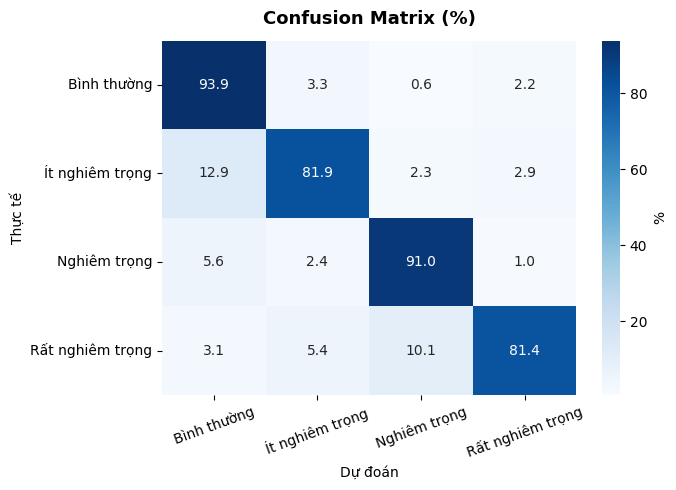

In [ ]:
from sklearn.metrics import confusion_matrix

# Biểu đồ: Confusion Matrix (%)
fig, ax = plt.subplots(figsize=(7, 5))

cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Blues",
    xticklabels=LABEL_LIST, yticklabels=LABEL_LIST,
    cbar_kws={"label": "%"}, ax=ax,
)
ax.set_title("Confusion Matrix (%)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Dự đoán")
ax.set_ylabel("Thực tế")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 12. Error Analysis

In [ ]:
from sklearn.metrics import confusion_matrix

# Assign X_test to test_texts, as it contains the cleaned text for the test set
test_texts = X_test

df_error = pd.DataFrame({
    'text_clean': test_texts,
    'true_label': test_trues,
    'pred_label': test_preds,
    'true_name': [TARGET_NAMES[i] for i in test_trues],
    'pred_name': [TARGET_NAMES[i] for i in test_preds]
})

df_error['is_error'] = df_error['true_label'] != df_error['pred_label']

print(f"Tỷ lệ dự đoán sai: {df_error['is_error'].mean():.2%}")

# Top lỗi nghiêm trọng
print("\n Một số trường hợp mô hình dự đoán sai:")
display(df_error[df_error['is_error']].head(20)[['text_clean', 'true_name', 'pred_name']])

Tỷ lệ dự đoán sai: 13.02%

 Một số trường hợp mô hình dự đoán sai:


,text_clean,true_name,pred_name
3,dùng ổn,Nghiêm trọng,Bình thường
10,ổn,Ít nghiêm trọng,Bình thường
18,Hay bị lỗi thanh toán,Rất nghiêm trọng,Ít nghiêm trọng
41,ổn,Ít nghiêm trọng,Bình thường
53,sao giờ vào chuyển tiền nó kêu tải zalopay trê...,Rất nghiêm trọng,Ít nghiêm trọng
56,ổn nha,Nghiêm trọng,Bình thường
68,tốt,Nghiêm trọng,Bình thường
74,rất tốt,Nghiêm trọng,Bình thường
82,5saa,Nghiêm trọng,Rất nghiêm trọng
87,sao mua rồi không thấy hoàn tiền nhỉ :)),Nghiêm trọng,Bình thường


## 13. Lưu F1 Score để so sánh

In [ ]:
phobert_f1 = f1_score(test_trues, test_preds, average="macro")
print(f"PhoBERT F1 Macro: {phobert_f1:.4f}")

PhoBERT F1 Macro: 0.8696


## 14. Phân tích Đặc trưng Từ vựng và Độ dài Văn bản

=== TỔNG QUAN BỘ DỮ LIỆU ===
Tổng số mẫu: 74,636
Số cột: 10

Phân bố nhãn:
predicted_label_name
Bình thường         66140
Nghiêm trọng         1073
Rất nghiêm trọng     4634
Ít nghiêm trọng      2789
Name: count, dtype: int64


/tmp/ipykernel_7010/616581544.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='predicted_label_name', y='word_count', ax=axes[1], palette='viridis')
/tmp/ipykernel_7010/616581544.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)


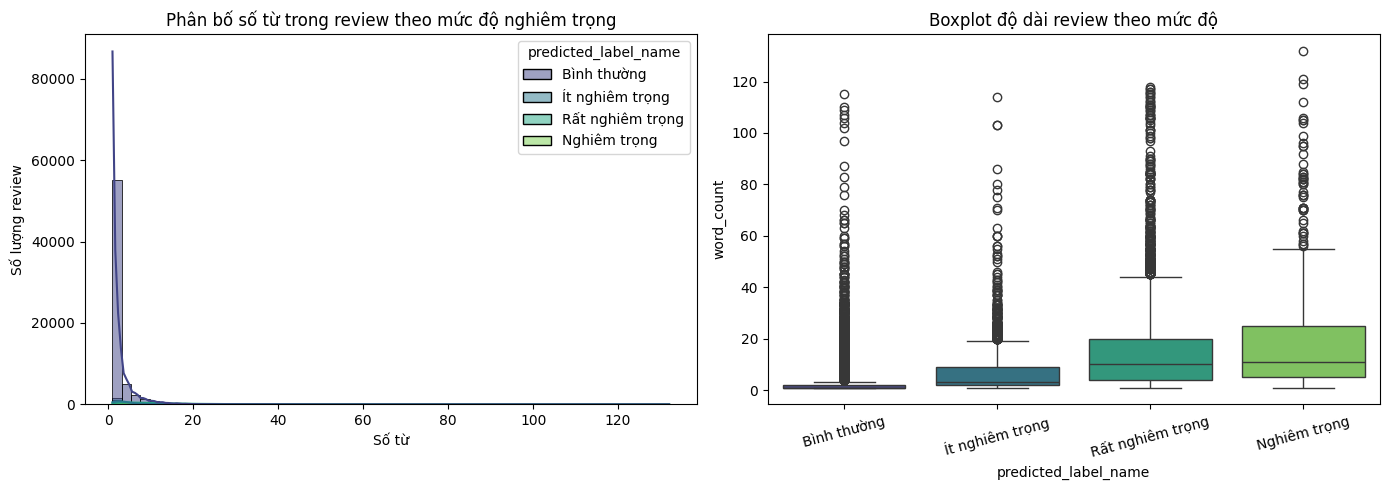

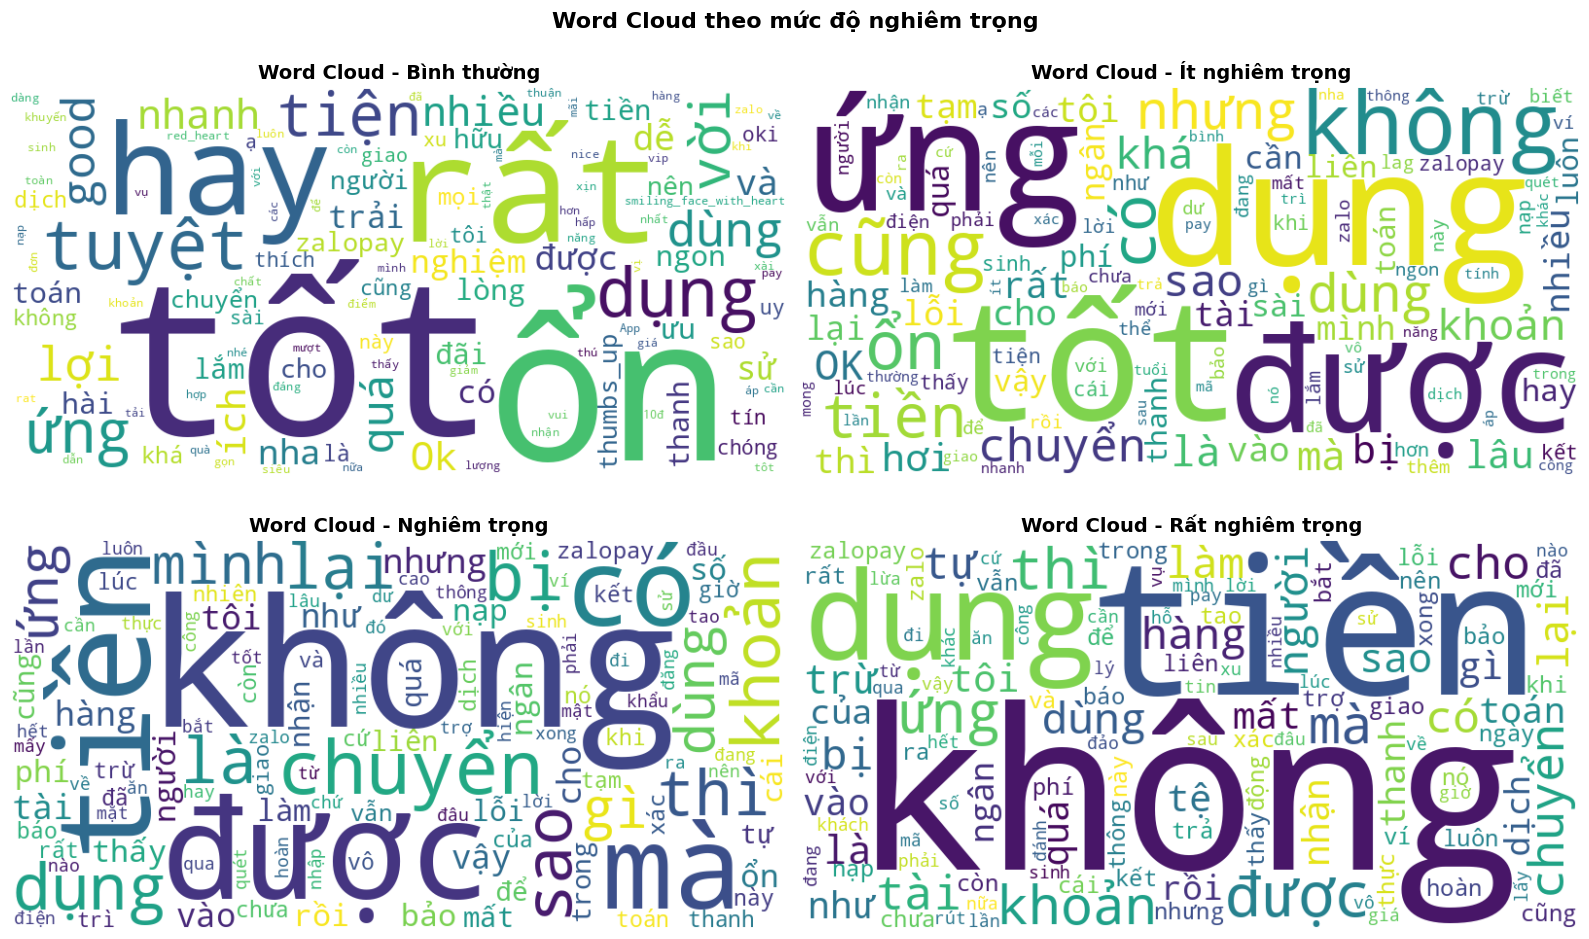


🔝 Top 15 từ xuất hiện nhiều nhất trong toàn bộ dataset:
  tốt             : 20,468 lần
  ổn              : 18,042 lần
  rất             : 8,786 lần
  dụng            : 7,168 lần
  hay             : 5,830 lần
  ứng             : 5,799 lần
  tuyệt           : 5,550 lần
  không           : 4,247 lần
  tiện            : 4,154 lần
  vời             : 3,462 lần
  dùng            : 3,342 lần
  được            : 3,219 lần
  tiền            : 3,073 lần
  quá             : 2,764 lần
  good            : 2,330 lần


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import numpy as np

# Sử dụng df_r từ notebook hiện tại
df_eda = df_r.copy()

# Thêm cột hỗ trợ
df_eda['text_length'] = df_eda['text_clean'].astype(str).str.len()
df_eda['word_count']  = df_eda['text_clean'].astype(str).apply(lambda x: len(x.split()))

print("=== TỔNG QUAN BỘ DỮ LIỆU ===")
print(f"Tổng số mẫu: {len(df_eda):,}")
print(f"Số cột: {df_eda.shape[1]}")
print("\nPhân bố nhãn:")
print(df_eda['predicted_label_name'].value_counts().sort_index())

# 1. Phân bố độ dài review
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_eda, x='word_count', hue='predicted_label_name',
             bins=60, kde=True, ax=axes[0], palette='viridis')
axes[0].set_title('Phân bố số từ trong review theo mức độ nghiêm trọng')
axes[0].set_xlabel('Số từ')
axes[0].set_ylabel('Số lượng review')

sns.boxplot(data=df_eda, x='predicted_label_name', y='word_count', ax=axes[1], palette='viridis')
axes[1].set_title('Boxplot độ dài review theo mức độ')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
plt.tight_layout()
plt.show()

# 2. Word Cloud theo từng lớp
TARGET_NAMES = ['Bình thường', 'Ít nghiêm trọng', 'Nghiêm trọng', 'Rất nghiêm trọng']

plt.figure(figsize=(16, 10))
for i, label_name in enumerate(TARGET_NAMES):
    plt.subplot(2, 2, i+1)
    text = " ".join(df_eda[df_eda['predicted_label_name'] == label_name]['text_clean'].astype(str))
    if len(text.strip()) > 10:
        wordcloud = WordCloud(width=800, height=400, background_color='white',
                            colormap='viridis', max_words=120, collocations=False).generate(text)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Word Cloud - {label_name}', fontsize=14, fontweight='bold')
    else:
        plt.text(0.5, 0.5, 'Không đủ dữ liệu', ha='center', va='center')
    plt.axis('off')
plt.suptitle('Word Cloud theo mức độ nghiêm trọng', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Top từ phổ biến
def get_top_words(text_series, n=20):
    all_text = " ".join(text_series.astype(str).str.lower())
    # Sử dụng underthesea nếu có, hoặc tách đơn giản
    words = all_text.split()
    return Counter(words).most_common(n)

print("\n🔝 Top 15 từ xuất hiện nhiều nhất trong toàn bộ dataset:")
top_words = get_top_words(df_eda['text_clean'], 15)
for word, count in top_words:
    print(f"  {word:<15} : {count:,} lần")

## 15. Phân tích lỗi (Error Analysis)




In [ ]:
from sklearn.metrics import confusion_matrix

# Assign X_test to test_texts, as it contains the cleaned text for the test set
test_texts = X_test

df_error = pd.DataFrame({
    'text_clean': test_texts,
    'true_label': test_trues,
    'pred_label': test_preds,
    'true_name': [TARGET_NAMES[i] for i in test_trues],
    'pred_name': [TARGET_NAMES[i] for i in test_preds]
})

df_error['is_error'] = df_error['true_label'] != df_error['pred_label']

print(f"Tỷ lệ dự đoán sai: {df_error['is_error'].mean():.2%}")

# Top lỗi nghiêm trọng
print("\n Một số trường hợp mô hình dự đoán sai:")
display(df_error[df_error['is_error']].head(20)[['text_clean', 'true_name', 'pred_name']])


Tỷ lệ dự đoán sai: 13.02%

 Một số trường hợp mô hình dự đoán sai:


,text_clean,true_name,pred_name
3,dùng ổn,Nghiêm trọng,Bình thường
10,ổn,Ít nghiêm trọng,Bình thường
18,Hay bị lỗi thanh toán,Rất nghiêm trọng,Ít nghiêm trọng
41,ổn,Ít nghiêm trọng,Bình thường
53,sao giờ vào chuyển tiền nó kêu tải zalopay trê...,Rất nghiêm trọng,Ít nghiêm trọng
56,ổn nha,Nghiêm trọng,Bình thường
68,tốt,Nghiêm trọng,Bình thường
74,rất tốt,Nghiêm trọng,Bình thường
82,5saa,Nghiêm trọng,Rất nghiêm trọng
87,sao mua rồi không thấy hoàn tiền nhỉ :)),Nghiêm trọng,Bình thường
